In [30]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print(df.shape)
display(df.head())
df.info()
display(df.describe().T)

(50000, 25)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3500
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Pages_Per_Session                3000
Days_Since_Last_Purchase         3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
dtype: int64


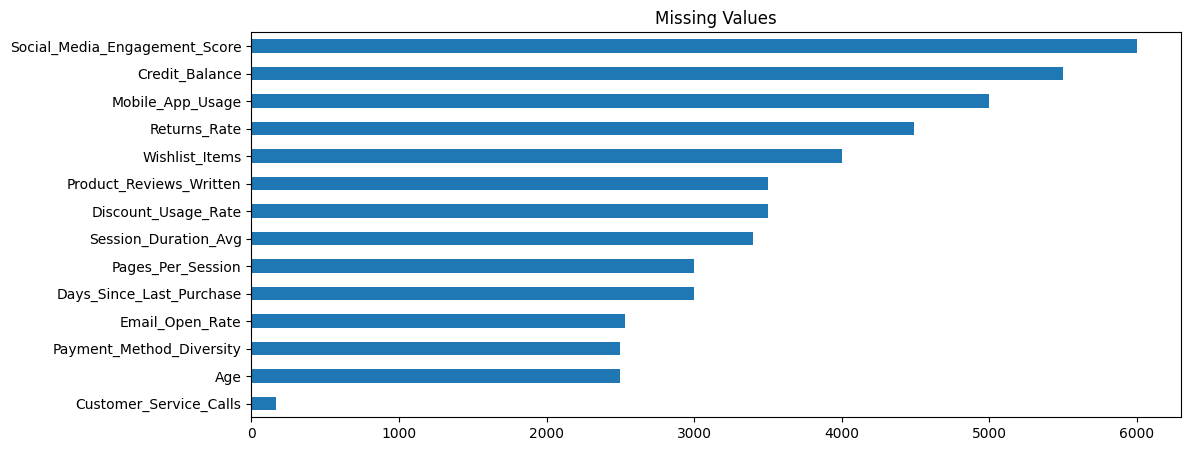

0


In [32]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

plt.figure(figsize=(12,5))
missing.sort_values().plot(kind='barh')
plt.title('Missing Values')
plt.show()

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum().sum())

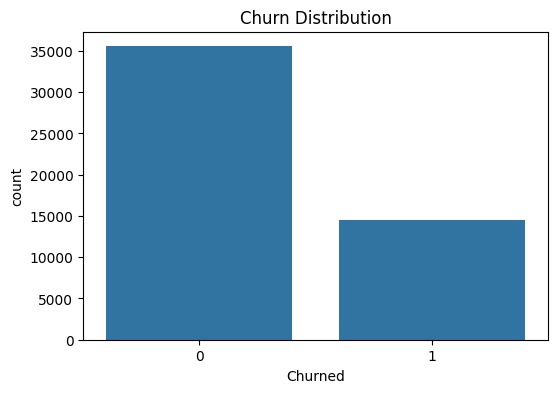

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churned', data=df)
plt.title('Churn Distribution')
plt.show()



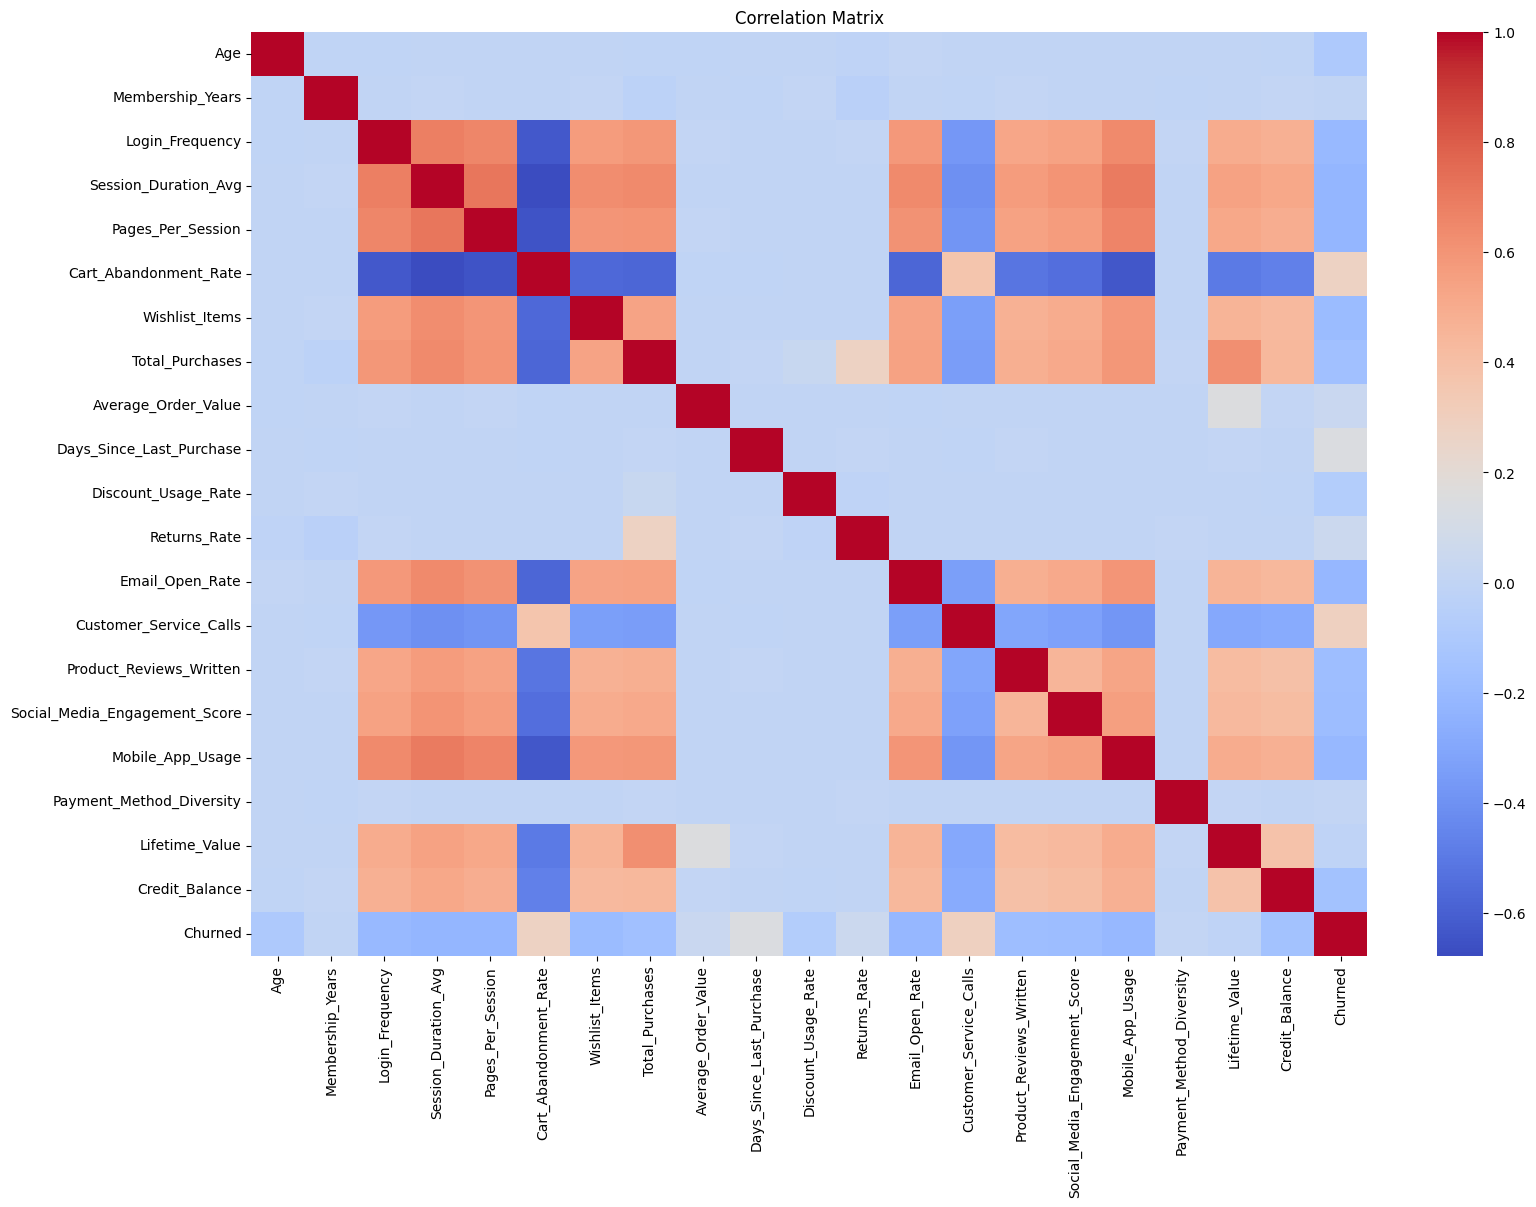

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,12))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

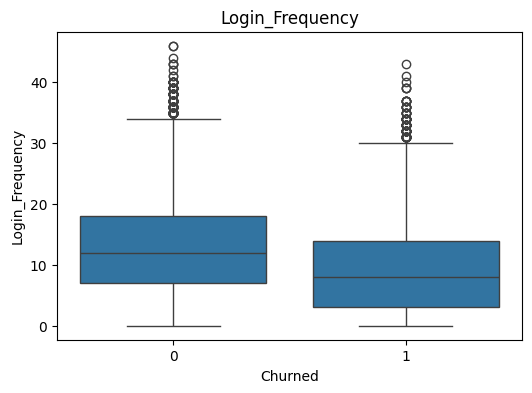

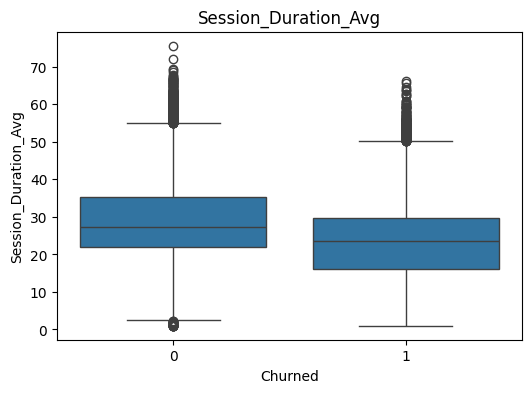

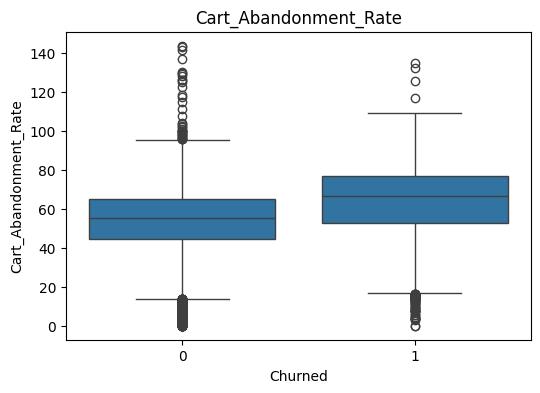

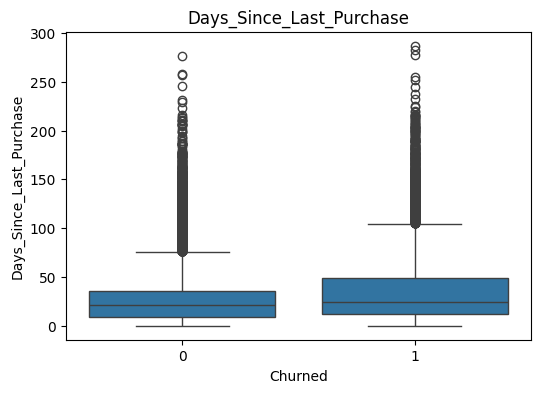

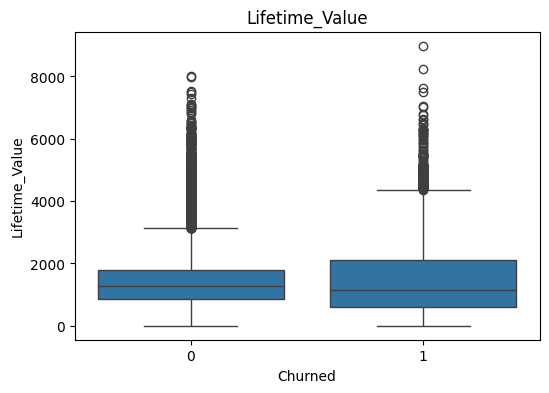

In [35]:
important_cols = [
    'Login_Frequency',
    'Session_Duration_Avg',
    'Cart_Abandonment_Rate',
    'Days_Since_Last_Purchase',
    'Lifetime_Value'
]

for col in important_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churned', y=col, data=df)
    plt.title(col)
    plt.show()

In [36]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

    df['Purchase_Frequency'] = (
    df['Total_Purchases'] /
    (df['Membership_Years'] + 1)
)

X = df.drop('Churned', axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)

print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.68      0.42      0.52      2890

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.76      0.78      0.76     10000



In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7110
           1       0.93      0.76      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.92      0.91      0.91     10000



In [39]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7110
           1       0.92      0.80      0.86      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.89      0.90     10000
weighted avg       0.92      0.92      0.92     10000



In [40]:
from sklearn.metrics import accuracy_score

models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ]
})

models_comparison

,Model,Accuracy
0,Logistic Regression,0.7754
1,Random Forest,0.9145
2,XGBoost,0.9238


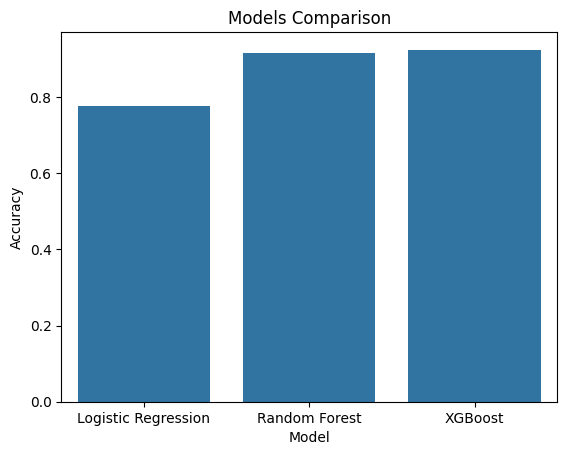

In [41]:
sns.barplot(
    data=models_comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Models Comparison')
plt.show()

ROC-AUC: 0.930264138914439


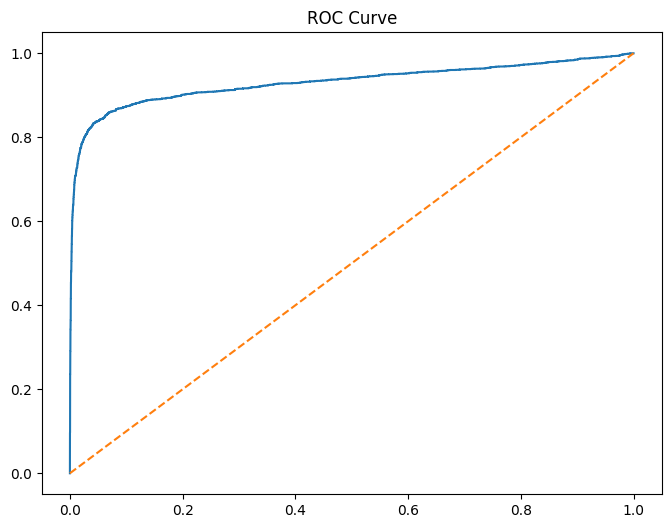

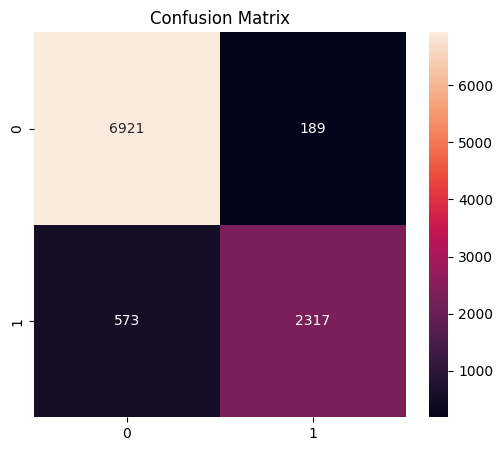

In [42]:
xgb_probs = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, xgb_probs)

print('ROC-AUC:', auc)

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve')
plt.show()

cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

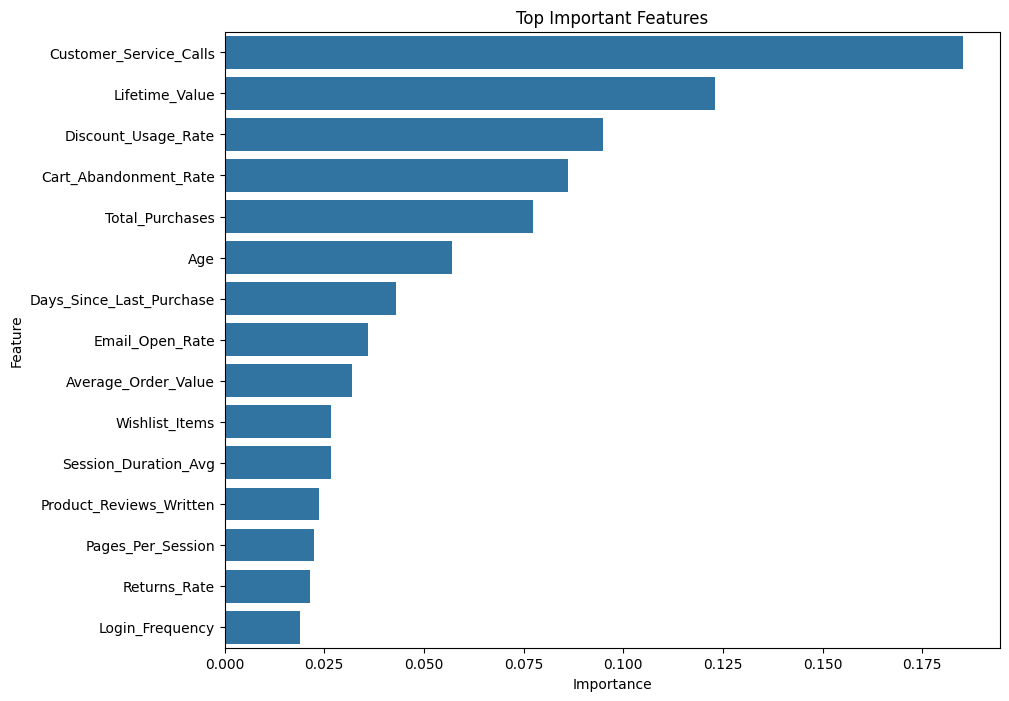

In [43]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top Important Features')
plt.show()

Business Insights:

1. Customers with high inactivity are more likely to churn.

2. Login frequency strongly affects customer retention.

3. Customers with high cart abandonment rates have increased churn probability.

4. Engagement metrics are strong indicators of customer loyalty.